In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import arff
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

!wget -O asd_children.zip "https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip"
!unzip -o asd_children.zip
!ls

from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff('Autism-Child-Data.arff')
df = pd.DataFrame(data)

df.head()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

df['Class/ASD'].value_counts()

df['Class/ASD'] = df['Class/ASD'].map({'NO': 0, 'YES': 1})

df['Class/ASD'].value_counts()



--2026-03-30 13:11:15--  https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘asd_children.zip’

asd_children.zip        [ <=>                ]  39.14K  --.-KB/s    in 0.05s   

2026-03-30 13:11:16 (802 KB/s) - ‘asd_children.zip’ saved [40081]

Archive:  asd_children.zip
  inflating: Autism-Child-Data.arff  
  inflating: Autism-Screening-Child-Data Description.docx  
 asd_children.zip				 fig1_distribuicao_classes.png
 Autism-Child-Data.arff				 sample_data
'Autism-Screening-Child-Data Description.docx'


,count
Class/ASD,
0,151
1,141


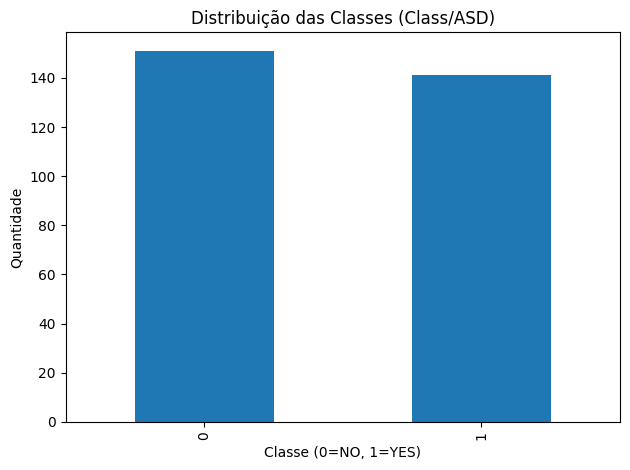

,age,result,A1_Score_1,A2_Score_1,A3_Score_1,A4_Score_1,A5_Score_1,A6_Score_1,A7_Score_1,A8_Score_1,...,contry_of_res_U.S. Outlying Islands,contry_of_res_United Arab Emirates,contry_of_res_United Kingdom,contry_of_res_United States,used_app_before_yes,relation_Health care professional,relation_Parent,relation_Relative,relation_Self,relation_self
0,6.0,5.0,True,True,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
1,6.0,5.0,True,True,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,6.0,5.0,True,True,False,False,False,True,True,True,...,False,False,False,False,True,False,False,False,False,False
3,5.0,4.0,False,True,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5.0,10.0,True,True,True,True,True,True,True,True,...,False,False,False,True,False,False,True,False,False,False


In [3]:
df["Class/ASD"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição das Classes (Class/ASD)")
plt.xlabel("Classe (0=NO, 1=YES)")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig("fig1_distribuicao_classes.png", dpi=300, bbox_inches="tight")
plt.show()

X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

X.head()

X = pd.get_dummies(X, drop_first=True)
X.head()


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

X.isna().sum().sort_values(ascending=False).head(10)

X = X.fillna(0)

X.columns

X = X.drop('result', axis=1)

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


Treino: (204, 82)
Teste: (88, 82)


In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))



Accuracy: 0.9886363636363636


In [6]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.97      0.99        37

    accuracy                           0.99        88
   macro avg       0.99      0.99      0.99        88
weighted avg       0.99      0.99      0.99        88



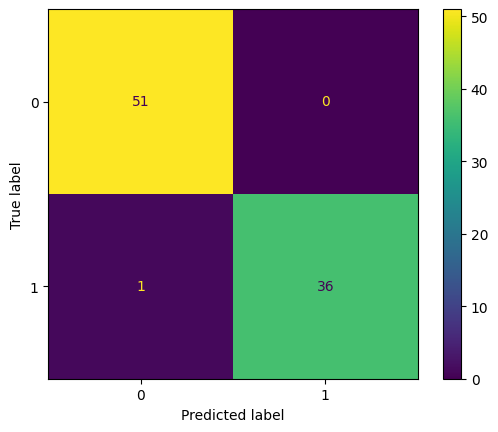

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


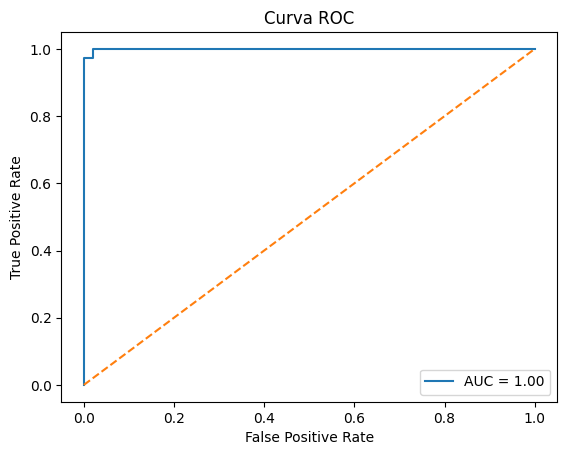

In [8]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


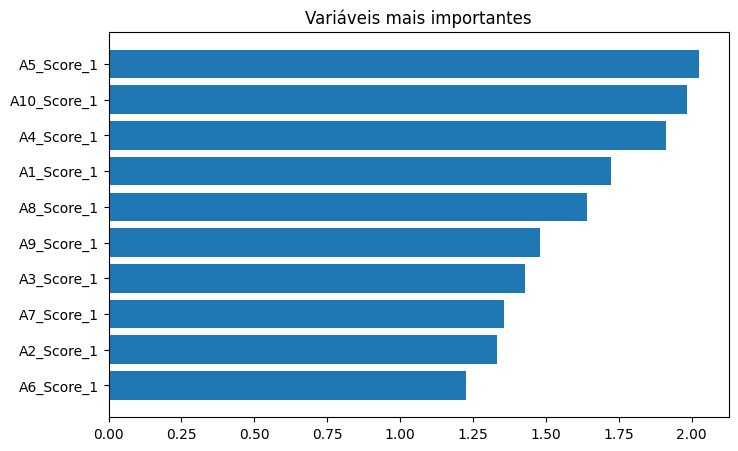

In [10]:
import numpy as np

importance = model.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

coef_df.head(10)

top = coef_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top['Feature'], top['Importance'])
plt.gca().invert_yaxis()
plt.title('Variáveis mais importantes')
plt.show()


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

plt.figure()


Random Forest Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        51
           1       0.85      0.95      0.90        37

    accuracy                           0.91        88
   macro avg       0.91      0.91      0.91        88
weighted avg       0.91      0.91      0.91        88



<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

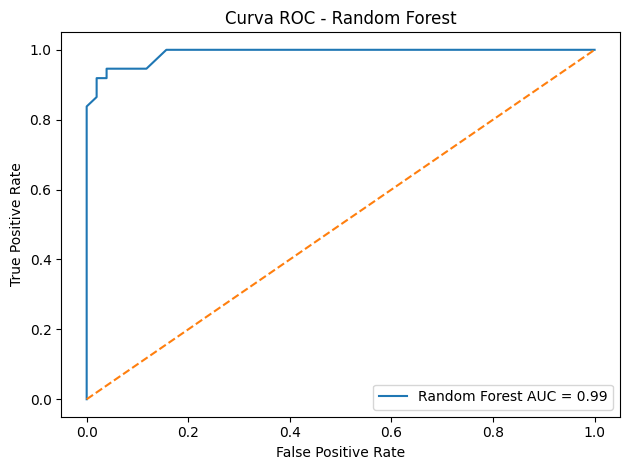

np.float64(0.9901960784313726)

In [15]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig("fig_rf_roc.png", dpi=300, bbox_inches="tight")
plt.show()

roc_auc_rf

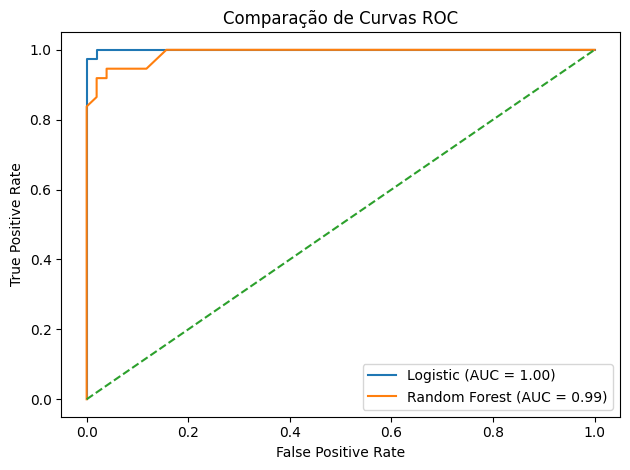

In [17]:
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic (AUC = {roc_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparação de Curvas ROC')
plt.legend()
plt.tight_layout()
plt.savefig("fig5_comparacao_roc.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
tab_abs = pd.crosstab(df["gender"], df["Class/ASD"])
tab_pct = pd.crosstab(df["gender"], df["Class/ASD"], normalize="index") * 100

tab_abs, tab_pct

(Class/ASD    0    1
 gender             
 f           46   38
 m          105  103,
 Class/ASD          0          1
 gender                         
 f          54.761905  45.238095
 m          50.480769  49.519231)

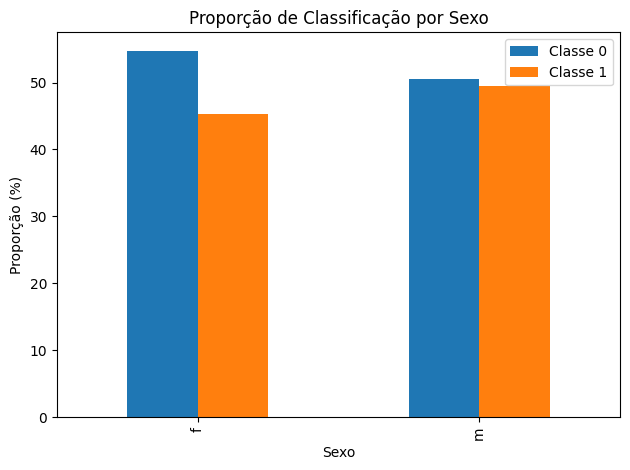

In [21]:
tab_pct.plot(kind="bar")
plt.title("Proporção de Classificação por Sexo")
plt.ylabel("Proporção (%)")
plt.xlabel("Sexo")
plt.legend(["Classe 0", "Classe 1"], loc="best")
plt.tight_layout()
plt.savefig("fig6_proporcao_por_sexo.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tab_abs)

print("Qui-quadrado:", chi2)
print("p-valor:", p)

Qui-quadrado: 0.28447044555963774
p-valor: 0.5937859868520012
